<a href="https://colab.research.google.com/github/haifabinduhaim/haifabinduhaim/blob/main/PMO_assistant.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [76]:
# ============================================
# PMO Synthetic Data & Reporting Assistant
# Cell 1 - Install & Import Libraries
# ============================================

!pip -q install pandas numpy matplotlib seaborn gspread \
    google-api-python-client google-auth-httplib2 \
    google-auth-oauthlib sdv scikit-learn

In [77]:
# ============================================
# PMO Synthetic Data & Reporting Assistant
# Cell 2 - Import Libraries
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime, timedelta

print("Libraries imported successfully!")

Libraries imported successfully!


In [78]:
# ============================================
# Cell 3 - Authenticate with Google
# ============================================

from google.colab import auth
import gspread
from google.auth import default

# Authenticate Google account
auth.authenticate_user()

# Get Google credentials
creds, _ = default()

# Authorize gspread
gc = gspread.authorize(creds)

print("Google authentication successful!")

Google authentication successful!


In [79]:
# ============================================
# Cell 4 - Load Data from Google Sheets
# ============================================

# اسم ملف Google Sheets
SPREADSHEET_NAME = "PMO_Project_Data"

# فتح ملف Google Sheets
spreadsheet = gc.open(SPREADSHEET_NAME)

# اختيار أول Sheet داخل الملف
worksheet = spreadsheet.sheet1

# قراءة البيانات
data = worksheet.get_all_records()

# تحويل البيانات إلى Pandas DataFrame
df = pd.DataFrame(data)

# عرض معلومات بسيطة
print("Google Sheet loaded successfully!")
print(f"Number of projects: {len(df)}")
print(f"Number of columns: {len(df.columns)}")

# عرض أول 5 مشاريع
display(df.head())

Google Sheet loaded successfully!
Number of projects: 6
Number of columns: 9


,Project,Department,Status,Progress,Budget,Spent,Risk,Start,End
0,Project A,IT,On Track,75,500000,380000,Low,2026-01-01,2026-09-30
1,Project B,Finance,Delayed,45,800000,620000,High,2026-02-01,2026-12-31
2,Project C,HR,At Risk,60,300000,250000,Medium,2026-03-01,2026-10-30
3,Project D,Operations,Completed,100,450000,440000,Low,2025-01-01,2026-03-30
4,Project E,IT,On Track,80,900000,700000,Medium,2026-02-15,2026-11-30


In [80]:
# ============================================
# Cell 5 - PMO Data Validation
# ============================================

required_columns = [
    "Project",
    "Department",
    "Status",
    "Progress",
    "Budget",
    "Spent",
    "Risk",
    "Start",
    "End"
]

print("========================================")
print("       PMO DATA VALIDATION")
print("========================================")

# 1. Check required columns
missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

if missing_columns:
    print("❌ Missing columns:")
    print(missing_columns)
else:
    print("✓ All required columns exist")


# 2. Check empty values
missing_values = df[required_columns].isnull().sum()

if missing_values.sum() == 0:
    print("✓ No missing values found")
else:
    print("⚠ Missing values detected:")
    print(missing_values[missing_values > 0])


# 3. Convert numeric columns
df["Progress"] = pd.to_numeric(
    df["Progress"],
    errors="coerce"
)

df["Budget"] = pd.to_numeric(
    df["Budget"],
    errors="coerce"
)

df["Spent"] = pd.to_numeric(
    df["Spent"],
    errors="coerce"
)


# 4. Check Progress range
invalid_progress = df[
    (df["Progress"] < 0) |
    (df["Progress"] > 100)
]

if len(invalid_progress) == 0:
    print("✓ Progress values are valid")
else:
    print(
        f"⚠ {len(invalid_progress)} "
        "invalid Progress values found"
    )


# 5. Check Budget and Spent
invalid_financial = df[
    (df["Budget"] < 0) |
    (df["Spent"] < 0)
]

if len(invalid_financial) == 0:
    print("✓ Budget and Spent values are valid")
else:
    print(
        f"⚠ {len(invalid_financial)} "
        "invalid financial values found"
    )


# 6. Check Status values
allowed_statuses = [
    "On Track",
    "At Risk",
    "Delayed",
    "Completed"
]

invalid_status = df[
    ~df["Status"].isin(allowed_statuses)
]

if len(invalid_status) == 0:
    print("✓ Status values are valid")
else:
    print(
        f"⚠ {len(invalid_status)} "
        "invalid Status values found"
    )


# 7. Check Risk values
allowed_risks = [
    "Low",
    "Medium",
    "High"
]

invalid_risk = df[
    ~df["Risk"].isin(allowed_risks)
]

if len(invalid_risk) == 0:
    print("✓ Risk values are valid")
else:
    print(
        f"⚠ {len(invalid_risk)} "
        "invalid Risk values found"
    )


# 8. Convert dates
df["Start"] = pd.to_datetime(
    df["Start"],
    errors="coerce"
)

df["End"] = pd.to_datetime(
    df["End"],
    errors="coerce"
)

invalid_dates = df[
    df["Start"].isna() |
    df["End"].isna() |
    (df["End"] < df["Start"])
]

if len(invalid_dates) == 0:
    print("✓ Date values are valid")
else:
    print(
        f"⚠ {len(invalid_dates)} "
        "invalid date records found"
    )


print("========================================")
print("Validation completed.")
print("========================================")

       PMO DATA VALIDATION
✓ All required columns exist
✓ No missing values found
✓ Progress values are valid
✓ Budget and Spent values are valid
✓ Status values are valid
✓ Risk values are valid
✓ Date values are valid
Validation completed.


In [81]:
# ============================================
# Cell 6 - PMO Portfolio Analysis
# ============================================

print("========================================")
print("       PMO PORTFOLIO ANALYSIS")
print("========================================")

# --------------------------------------------
# 1. Calculate Variance
# --------------------------------------------

df["Variance"] = df["Budget"] - df["Spent"]


# --------------------------------------------
# 2. Project Status Analysis
# --------------------------------------------

total_projects = len(df)

status_counts = df["Status"].value_counts()

on_track_projects = status_counts.get("On Track", 0)
at_risk_projects = status_counts.get("At Risk", 0)
delayed_projects = status_counts.get("Delayed", 0)
completed_projects = status_counts.get("Completed", 0)


# --------------------------------------------
# 3. Progress Analysis
# --------------------------------------------

average_progress = df["Progress"].mean()


# --------------------------------------------
# 4. Financial Analysis
# --------------------------------------------

total_budget = df["Budget"].sum()
total_spent = df["Spent"].sum()
total_variance = df["Variance"].sum()

spending_percentage = (
    total_spent / total_budget * 100
    if total_budget > 0
    else 0
)


# --------------------------------------------
# 5. Risk Analysis
# --------------------------------------------

risk_counts = df["Risk"].value_counts()

low_risk = risk_counts.get("Low", 0)
medium_risk = risk_counts.get("Medium", 0)
high_risk = risk_counts.get("High", 0)


# --------------------------------------------
# 6. Display Portfolio Results
# --------------------------------------------

print(f"Total Projects       : {total_projects}")
print(f"On Track             : {on_track_projects}")
print(f"At Risk              : {at_risk_projects}")
print(f"Delayed              : {delayed_projects}")
print(f"Completed            : {completed_projects}")

print("----------------------------------------")

print(f"Average Progress     : {average_progress:.1f}%")

print("----------------------------------------")

print(f"Total Budget         : ${total_budget:,.0f}")
print(f"Total Spent          : ${total_spent:,.0f}")
print(f"Total Variance       : ${total_variance:,.0f}")
print(f"Spending Percentage  : {spending_percentage:.1f}%")

print("----------------------------------------")

print(f"Low Risk             : {low_risk}")
print(f"Medium Risk          : {medium_risk}")
print(f"High Risk            : {high_risk}")

print("========================================")
print("Analysis completed successfully!")
print("========================================")


       PMO PORTFOLIO ANALYSIS
Total Projects       : 6
On Track             : 3
At Risk              : 1
Delayed              : 1
Completed            : 1
----------------------------------------
Average Progress     : 75.0%
----------------------------------------
Total Budget         : $3,750,000
Total Spent          : $3,090,000
Total Variance       : $660,000
Spending Percentage  : 82.4%
----------------------------------------
Low Risk             : 2
Medium Risk          : 3
High Risk            : 1
Analysis completed successfully!


In [82]:
# ============================================
# Cell 7 - Project-Level Analysis
# ============================================

# Make a copy so we keep the original data safe
project_analysis = df.copy()

# --------------------------------------------
# 1. Budget Variance
# --------------------------------------------

project_analysis["Variance"] = (
    project_analysis["Budget"] -
    project_analysis["Spent"]
)


# --------------------------------------------
# 2. Budget Utilization
# --------------------------------------------

project_analysis["Budget Utilization"] = (
    project_analysis["Spent"] /
    project_analysis["Budget"] * 100
)


# --------------------------------------------
# 3. Days Remaining
# --------------------------------------------

today = pd.Timestamp.today().normalize()

project_analysis["Days Remaining"] = (
    project_analysis["End"] - today
).dt.days


# --------------------------------------------
# 4. Schedule Indicator
# --------------------------------------------

def get_schedule_indicator(row):

    if row["Status"] == "Completed":
        return "Completed"

    elif row["Status"] == "Delayed":
        return "Delayed"

    elif row["Days Remaining"] < 30:
        return "Approaching Deadline"

    else:
        return "Within Timeline"


project_analysis["Schedule Indicator"] = (
    project_analysis.apply(
        get_schedule_indicator,
        axis=1
    )
)


# --------------------------------------------
# 5. Display Project Analysis
# --------------------------------------------

columns_to_display = [
    "Project",
    "Department",
    "Status",
    "Progress",
    "Budget",
    "Spent",
    "Variance",
    "Budget Utilization",
    "Risk",
    "Days Remaining",
    "Schedule Indicator"
]

display(
    project_analysis[columns_to_display]
)

,Project,Department,Status,Progress,Budget,Spent,Variance,Budget Utilization,Risk,Days Remaining,Schedule Indicator
0,Project A,IT,On Track,75,500000,380000,120000,76.000000,Low,16,Approaching Deadline
1,Project B,Finance,Delayed,45,800000,620000,180000,77.500000,High,108,Delayed
2,Project C,HR,At Risk,60,300000,250000,50000,83.333333,Medium,46,Within Timeline
3,Project D,Operations,Completed,100,450000,440000,10000,97.777778,Low,-168,Completed
4,Project E,IT,On Track,80,900000,700000,200000,77.777778,Medium,77,Within Timeline
5,Project F,IT,On Track,90,800000,700000,100000,87.500000,Medium,52,Within Timeline


In [83]:
# ============================================
# Cell 8 - PMO Attention Indicators
# ============================================

attention_df = project_analysis.copy()


# --------------------------------------------
# 1. Create attention indicators
# --------------------------------------------

attention_df["Attention Indicators"] = ""


# High Risk
attention_df.loc[
    attention_df["Risk"] == "High",
    "Attention Indicators"
] += "High Risk; "


# Delayed Projects
attention_df.loc[
    attention_df["Status"] == "Delayed",
    "Attention Indicators"
] += "Delayed; "


# Approaching Deadline
attention_df.loc[
    attention_df["Schedule Indicator"] == "Approaching Deadline",
    "Attention Indicators"
] += "Approaching Deadline; "


# High Budget Utilization
attention_df.loc[
    attention_df["Budget Utilization"] >= 90,
    "Attention Indicators"
] += "High Budget Utilization; "


# Low Progress
attention_df.loc[
    attention_df["Progress"] < 50,
    "Attention Indicators"
] += "Low Progress; "


# --------------------------------------------
# 2. Clean empty indicators
# --------------------------------------------

attention_df["Attention Indicators"] = (
    attention_df["Attention Indicators"]
    .str.rstrip("; ")
)


# --------------------------------------------
# 3. Create PMO Attention Flag
# --------------------------------------------

attention_df["PMO Attention"] = np.where(
    attention_df["Attention Indicators"] != "",
    "Review",
    "No Immediate Indicator"
)


# --------------------------------------------
# 4. Display results
# --------------------------------------------

attention_columns = [
    "Project",
    "Status",
    "Progress",
    "Budget Utilization",
    "Risk",
    "Days Remaining",
    "Attention Indicators",
    "PMO Attention"
]

display(
    attention_df[attention_columns]
)

,Project,Status,Progress,Budget Utilization,Risk,Days Remaining,Attention Indicators,PMO Attention
0,Project A,On Track,75,76.000000,Low,16,Approaching Deadline,Review
1,Project B,Delayed,45,77.500000,High,108,High Risk; Delayed; Low Progress,Review
2,Project C,At Risk,60,83.333333,Medium,46,,No Immediate Indicator
3,Project D,Completed,100,97.777778,Low,-168,High Budget Utilization,Review
4,Project E,On Track,80,77.777778,Medium,77,,No Immediate Indicator
5,Project F,On Track,90,87.500000,Medium,52,,No Immediate Indicator


In [84]:
# ============================================
# Cell 9 - Executive Summary Generator
# ============================================

def generate_executive_summary(df):

    total_projects = len(df)

    status_counts = df["Status"].value_counts()

    on_track = status_counts.get("On Track", 0)
    at_risk = status_counts.get("At Risk", 0)
    delayed = status_counts.get("Delayed", 0)
    completed = status_counts.get("Completed", 0)

    average_progress = df["Progress"].mean()

    total_budget = df["Budget"].sum()
    total_spent = df["Spent"].sum()

    spending_percentage = (
        total_spent / total_budget * 100
        if total_budget > 0
        else 0
    )

    high_risk = (
        df["Risk"] == "High"
    ).sum()

    # ----------------------------------------
    # Generate summary
    # ----------------------------------------

    summary = f"""
EXECUTIVE SUMMARY
-----------------

The portfolio currently contains {total_projects} projects.

Project Status:
- {on_track} project(s) are On Track.
- {at_risk} project(s) are At Risk.
- {delayed} project(s) are Delayed.
- {completed} project(s) are Completed.

The average portfolio progress is {average_progress:.1f}%.

Financial Overview:
- Total planned budget: ${total_budget:,.0f}
- Total spending: ${total_spent:,.0f}
- Budget utilization: {spending_percentage:.1f}%

Risk Overview:
- {high_risk} project(s) are currently classified as High Risk.

The above summary is based on the information available
in the project portfolio data and is intended to support
PMO monitoring and reporting.
"""

    return summary.strip()


# Generate summary
executive_summary = generate_executive_summary(
    project_analysis
)

# Display summary
print(executive_summary)


EXECUTIVE SUMMARY
-----------------

The portfolio currently contains 6 projects.

Project Status:
- 3 project(s) are On Track.
- 1 project(s) are At Risk.
- 1 project(s) are Delayed.
- 1 project(s) are Completed.

The average portfolio progress is 75.0%.

Financial Overview:
- Total planned budget: $3,750,000
- Total spending: $3,090,000
- Budget utilization: 82.4%

Risk Overview:
- 1 project(s) are currently classified as High Risk.

The above summary is based on the information available
in the project portfolio data and is intended to support
PMO monitoring and reporting.


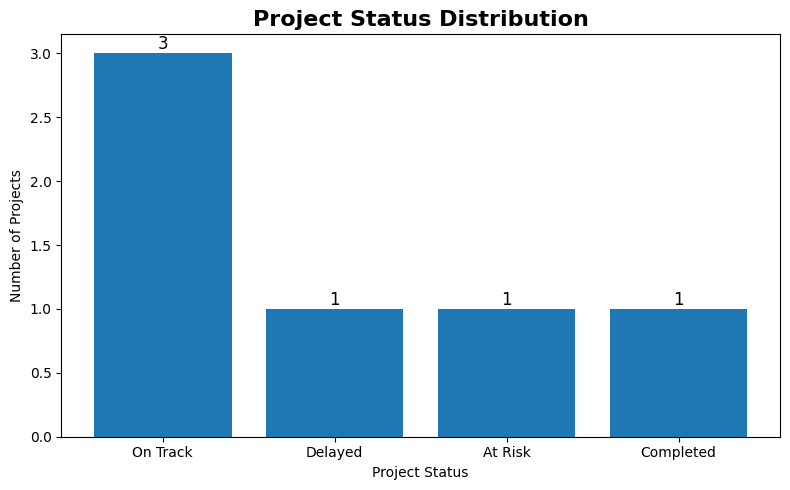

In [85]:
# ============================================
# Cell 10 - Project Status Dashboard
# ============================================

# Count projects by status
status_data = df["Status"].value_counts()

# Create figure
plt.figure(figsize=(8, 5))

# Create bar chart
bars = plt.bar(
    status_data.index,
    status_data.values
)

# Add values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        str(int(height)),
        ha="center",
        va="bottom",
        fontsize=12
    )

# Chart title
plt.title(
    "Project Status Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Project Status")
plt.ylabel("Number of Projects")

plt.tight_layout()

# Display chart
plt.show()


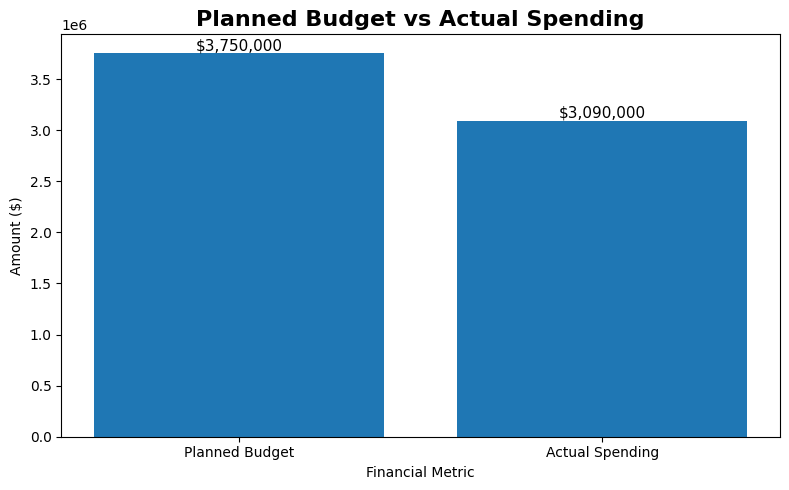

In [86]:
# ============================================
# Cell 11 - Budget vs Actual Spending
# ============================================

# Calculate total budget and spending
total_budget = df["Budget"].sum()
total_spent = df["Spent"].sum()

# Data for chart
financial_data = pd.Series({
    "Planned Budget": total_budget,
    "Actual Spending": total_spent
})

# Create figure
plt.figure(figsize=(8, 5))

# Create bars
bars = plt.bar(
    financial_data.index,
    financial_data.values
)

# Add values on top of bars
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"${height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=11
    )

# Title
plt.title(
    "Planned Budget vs Actual Spending",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Financial Metric")
plt.ylabel("Amount ($)")

plt.tight_layout()

# Display chart
plt.show()

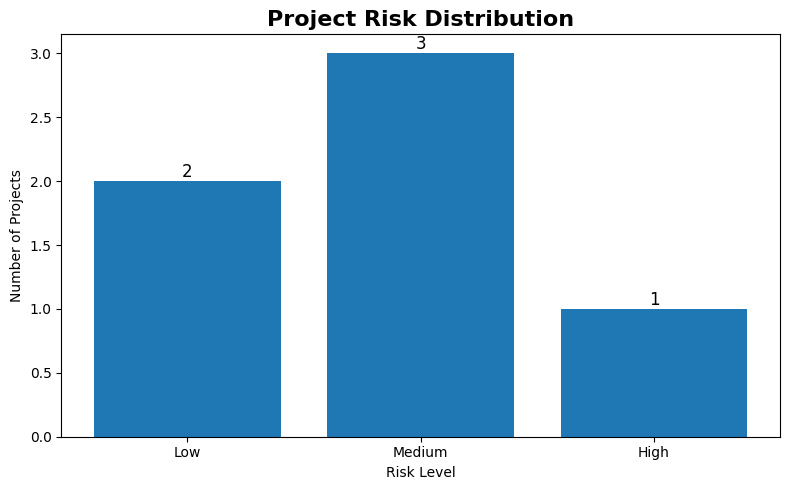

In [87]:
# ============================================
# Cell 12 - Risk Distribution
# ============================================

# Count projects by risk level
risk_data = df["Risk"].value_counts()

# Keep risk levels in logical order
risk_order = ["Low", "Medium", "High"]

risk_data = risk_data.reindex(
    risk_order,
    fill_value=0
)

# Create figure
plt.figure(figsize=(8, 5))

# Create bars
bars = plt.bar(
    risk_data.index,
    risk_data.values
)

# Add values on top of bars
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        str(int(height)),
        ha="center",
        va="bottom",
        fontsize=12
    )

# Title
plt.title(
    "Project Risk Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Risk Level")
plt.ylabel("Number of Projects")

plt.tight_layout()

# Display chart
plt.show()

In [88]:
# ============================================
# Cell 13 - Timeline Analysis
# ============================================

timeline_df = project_analysis.copy()

# --------------------------------------------
# Classify timeline status
# --------------------------------------------

def classify_timeline(row):

    if row["Status"] == "Completed":
        return "Completed"

    elif row["Status"] == "Delayed":
        return "Delayed"

    elif row["Days Remaining"] <= 30:
        return "Approaching Deadline"

    else:
        return "Within Timeline"


timeline_df["Timeline Status"] = timeline_df.apply(
    classify_timeline,
    axis=1
)


# --------------------------------------------
# Count timeline categories
# --------------------------------------------

timeline_counts = (
    timeline_df["Timeline Status"]
    .value_counts()
)


# --------------------------------------------
# Display timeline summary
# --------------------------------------------

print("========================================")
print("          TIMELINE ANALYSIS")
print("========================================")

for category in [
    "Within Timeline",
    "Approaching Deadline",
    "Delayed",
    "Completed"
]:

    count = timeline_counts.get(category, 0)

    print(f"{category:<25}: {count}")

print("========================================")


# --------------------------------------------
# Display project timeline table
# --------------------------------------------

timeline_columns = [
    "Project",
    "Status",
    "Start",
    "End",
    "Days Remaining",
    "Timeline Status"
]

display(
    timeline_df[timeline_columns]
)

          TIMELINE ANALYSIS
Within Timeline          : 3
Approaching Deadline     : 1
Delayed                  : 1
Completed                : 1


,Project,Status,Start,End,Days Remaining,Timeline Status
0,Project A,On Track,2026-01-01,2026-09-30,16,Approaching Deadline
1,Project B,Delayed,2026-02-01,2026-12-31,108,Delayed
2,Project C,At Risk,2026-03-01,2026-10-30,46,Within Timeline
3,Project D,Completed,2025-01-01,2026-03-30,-168,Completed
4,Project E,On Track,2026-02-15,2026-11-30,77,Within Timeline
5,Project F,On Track,2026-02-13,2026-11-05,52,Within Timeline


In [89]:
# ============================================
# Cell 14 - PMO Dashboard KPIs
# ============================================

dashboard_kpis = pd.DataFrame({
    "KPI": [
        "Total Projects",
        "On Track Projects",
        "At Risk Projects",
        "Delayed Projects",
        "Completed Projects",
        "Average Progress",
        "Total Budget",
        "Total Spent",
        "Budget Variance",
        "Budget Utilization",
        "High Risk Projects"
    ],

    "Value": [
        total_projects,
        on_track_projects,
        at_risk_projects,
        delayed_projects,
        completed_projects,
        round(average_progress, 1),
        total_budget,
        total_spent,
        total_variance,
        round(spending_percentage, 1),
        high_risk
    ]
})

display(dashboard_kpis)

,KPI,Value
0,Total Projects,6.0
1,On Track Projects,3.0
2,At Risk Projects,1.0
3,Delayed Projects,1.0
4,Completed Projects,1.0
5,Average Progress,75.0
6,Total Budget,3750000.0
7,Total Spent,3090000.0
8,Budget Variance,660000.0
9,Budget Utilization,82.4


In [90]:
# ============================================
# Cell 15 - Generate PMO Report
# ============================================

print("=" * 60)
print("              PMO PORTFOLIO REPORT")
print("=" * 60)

print("\n1. PORTFOLIO OVERVIEW")
print("-" * 60)

print(f"Total Projects      : {total_projects}")
print(f"Average Progress    : {average_progress:.1f}%")
print(f"On Track            : {on_track_projects}")
print(f"At Risk             : {at_risk_projects}")
print(f"Delayed             : {delayed_projects}")
print(f"Completed           : {completed_projects}")

print("\n2. FINANCIAL OVERVIEW")
print("-" * 60)

print(f"Planned Budget      : ${total_budget:,.0f}")
print(f"Actual Spending     : ${total_spent:,.0f}")
print(f"Budget Variance     : ${total_variance:,.0f}")
print(f"Budget Utilization  : {spending_percentage:.1f}%")

print("\n3. RISK OVERVIEW")
print("-" * 60)

print(f"Low Risk            : {low_risk}")
print(f"Medium Risk         : {medium_risk}")
print(f"High Risk           : {high_risk}")

print("\n4. TIMELINE OVERVIEW")
print("-" * 60)

for category in [
    "Within Timeline",
    "Approaching Deadline",
    "Delayed",
    "Completed"
]:

    count = timeline_counts.get(category, 0)

    print(f"{category:<25}: {count}")

print("\n5. PROJECTS REQUIRING REVIEW")
print("-" * 60)

review_projects = attention_df[
    attention_df["PMO Attention"] == "Review"
]

if len(review_projects) == 0:

    print("No projects currently have attention indicators.")

else:

    for _, row in review_projects.iterrows():

        print(
            f"- {row['Project']}: "
            f"{row['Attention Indicators']}"
        )

print("\n" + "=" * 60)
print("              END OF REPORT")
print("=" * 60)

              PMO PORTFOLIO REPORT

1. PORTFOLIO OVERVIEW
------------------------------------------------------------
Total Projects      : 6
Average Progress    : 75.0%
On Track            : 3
At Risk             : 1
Delayed             : 1
Completed           : 1

2. FINANCIAL OVERVIEW
------------------------------------------------------------
Planned Budget      : $3,750,000
Actual Spending     : $3,090,000
Budget Variance     : $660,000
Budget Utilization  : 82.4%

3. RISK OVERVIEW
------------------------------------------------------------
Low Risk            : 2
Medium Risk         : 3
High Risk           : 1

4. TIMELINE OVERVIEW
------------------------------------------------------------
Within Timeline          : 3
Approaching Deadline     : 1
Delayed                  : 1
Completed                : 1

5. PROJECTS REQUIRING REVIEW
------------------------------------------------------------
- Project A: Approaching Deadline
- Project B: High Risk; Delayed; Low Progress
- P

In [91]:
# ============================================
# Cell 16 - Prepare Data for Synthetic Generation
# ============================================

# Columns coming directly from Google Sheets
synthetic_columns = [
    "Project",
    "Department",
    "Status",
    "Progress",
    "Budget",
    "Spent",
    "Risk",
    "Start",
    "End"
]

# Create a clean copy
synthetic_source = df[synthetic_columns].copy()

# Convert dates to string format for SDV
synthetic_source["Start"] = (
    synthetic_source["Start"]
    .dt.strftime("%Y-%m-%d")
)

synthetic_source["End"] = (
    synthetic_source["End"]
    .dt.strftime("%Y-%m-%d")
)

print("Synthetic data source prepared successfully!")
print(f"Rows    : {len(synthetic_source)}")
print(f"Columns : {len(synthetic_source.columns)}")

display(synthetic_source)

Synthetic data source prepared successfully!
Rows    : 6
Columns : 9


,Project,Department,Status,Progress,Budget,Spent,Risk,Start,End
0,Project A,IT,On Track,75,500000,380000,Low,2026-01-01,2026-09-30
1,Project B,Finance,Delayed,45,800000,620000,High,2026-02-01,2026-12-31
2,Project C,HR,At Risk,60,300000,250000,Medium,2026-03-01,2026-10-30
3,Project D,Operations,Completed,100,450000,440000,Low,2025-01-01,2026-03-30
4,Project E,IT,On Track,80,900000,700000,Medium,2026-02-15,2026-11-30
5,Project F,IT,On Track,90,800000,700000,Medium,2026-02-13,2026-11-05


In [92]:
# ============================================
# Cell 17 - Generate Synthetic Data with SDV
# ============================================

from sdv.metadata import SingleTableMetadata
from sdv.single_table import GaussianCopulaSynthesizer

# --------------------------------------------
# 1. Create metadata
# --------------------------------------------

metadata = SingleTableMetadata()

metadata.detect_from_dataframe(
    data=synthetic_source
)

# --------------------------------------------
# 2. Create synthesizer
# --------------------------------------------

synthesizer = GaussianCopulaSynthesizer(
    metadata
)

# --------------------------------------------
# 3. Train synthesizer
# --------------------------------------------

synthesizer.fit(
    synthetic_source
)

print("SDV model trained successfully!")


# --------------------------------------------
# 4. Generate synthetic projects
# --------------------------------------------

synthetic_df = synthesizer.sample(
    num_rows=100
)

print(
    f"Generated {len(synthetic_df)} synthetic projects."
)

display(
    synthetic_df.head(10)
)

/usr/local/lib/python3.13/dist-packages/sdv/single_table/base.py:183: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.13/dist-packages/sdv/single_table/base.py:139: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


SDV model trained successfully!
Generated 100 synthetic projects.


,Project,Department,Status,Progress,Budget,Spent,Risk,Start,End
0,sdv-id-TvWZWA,Finance,On Track,82,318191,301296,High,2026-03-01,2026-11-23
1,sdv-id-JsKfKl,IT,On Track,63,725376,619893,High,2025-01-05,2026-12-30
2,sdv-id-xTpaJc,HR,On Track,95,583782,446302,Medium,2026-03-01,2026-07-21
3,sdv-id-JcHYKx,Operations,Completed,91,315246,263557,Low,2026-03-01,2026-12-16
4,sdv-id-CyjVDD,HR,On Track,98,531991,373686,Low,2025-02-19,2026-05-18
5,sdv-id-FydiTx,HR,On Track,96,888645,677469,Low,2025-01-01,2026-11-29
6,sdv-id-ZjZesn,IT,On Track,80,785210,654900,Medium,2026-03-01,2026-12-19
7,sdv-id-OqRrVF,HR,On Track,68,898191,691486,Medium,2025-01-01,2026-12-30
8,sdv-id-wmjMak,IT,On Track,78,899638,698328,Medium,2026-02-27,2026-12-29
9,sdv-id-UwrSKp,Finance,Delayed,62,869499,699360,Medium,2026-03-01,2026-12-30


In [93]:
# ============================================
# Cell 18 - Inspect Synthetic Data
# ============================================

print("========================================")
print("       SYNTHETIC DATA PREVIEW")
print("========================================")

print(f"Number of synthetic projects: {len(synthetic_df)}")

print("\nStatus Distribution:")
print(
    synthetic_df["Status"]
    .value_counts()
)

print("\nRisk Distribution:")
print(
    synthetic_df["Risk"]
    .value_counts()
)

print("\nDepartment Distribution:")
print(
    synthetic_df["Department"]
    .value_counts()
)

print("\nSynthetic Data Sample:")
display(
    synthetic_df.head(10)
)

       SYNTHETIC DATA PREVIEW
Number of synthetic projects: 100

Status Distribution:
Status
On Track     79
Delayed       9
Completed     7
At Risk       5
Name: count, dtype: int64

Risk Distribution:
Risk
Medium    70
Low       17
High      13
Name: count, dtype: int64

Department Distribution:
Department
IT            38
HR            25
Finance       24
Operations    13
Name: count, dtype: int64

Synthetic Data Sample:


,Project,Department,Status,Progress,Budget,Spent,Risk,Start,End
0,sdv-id-TvWZWA,Finance,On Track,82,318191,301296,High,2026-03-01,2026-11-23
1,sdv-id-JsKfKl,IT,On Track,63,725376,619893,High,2025-01-05,2026-12-30
2,sdv-id-xTpaJc,HR,On Track,95,583782,446302,Medium,2026-03-01,2026-07-21
3,sdv-id-JcHYKx,Operations,Completed,91,315246,263557,Low,2026-03-01,2026-12-16
4,sdv-id-CyjVDD,HR,On Track,98,531991,373686,Low,2025-02-19,2026-05-18
5,sdv-id-FydiTx,HR,On Track,96,888645,677469,Low,2025-01-01,2026-11-29
6,sdv-id-ZjZesn,IT,On Track,80,785210,654900,Medium,2026-03-01,2026-12-19
7,sdv-id-OqRrVF,HR,On Track,68,898191,691486,Medium,2025-01-01,2026-12-30
8,sdv-id-wmjMak,IT,On Track,78,899638,698328,Medium,2026-02-27,2026-12-29
9,sdv-id-UwrSKp,Finance,Delayed,62,869499,699360,Medium,2026-03-01,2026-12-30


In [94]:
# ============================================
# Cell 19 - Anonymize Synthetic Project IDs
# ============================================

# Create unique synthetic project IDs
synthetic_df["Project"] = [
    f"SYN-PROJ-{i:04d}"
    for i in range(1, len(synthetic_df) + 1)
]

# Display first 10 records
print("Synthetic project IDs anonymized successfully!")

display(
    synthetic_df.head(10)
)

Synthetic project IDs anonymized successfully!


,Project,Department,Status,Progress,Budget,Spent,Risk,Start,End
0,SYN-PROJ-0001,Finance,On Track,82,318191,301296,High,2026-03-01,2026-11-23
1,SYN-PROJ-0002,IT,On Track,63,725376,619893,High,2025-01-05,2026-12-30
2,SYN-PROJ-0003,HR,On Track,95,583782,446302,Medium,2026-03-01,2026-07-21
3,SYN-PROJ-0004,Operations,Completed,91,315246,263557,Low,2026-03-01,2026-12-16
4,SYN-PROJ-0005,HR,On Track,98,531991,373686,Low,2025-02-19,2026-05-18
5,SYN-PROJ-0006,HR,On Track,96,888645,677469,Low,2025-01-01,2026-11-29
6,SYN-PROJ-0007,IT,On Track,80,785210,654900,Medium,2026-03-01,2026-12-19
7,SYN-PROJ-0008,HR,On Track,68,898191,691486,Medium,2025-01-01,2026-12-30
8,SYN-PROJ-0009,IT,On Track,78,899638,698328,Medium,2026-02-27,2026-12-29
9,SYN-PROJ-0010,Finance,Delayed,62,869499,699360,Medium,2026-03-01,2026-12-30


In [95]:
# ============================================
# Cell 20 - Unified PMO Analysis Engine
# ============================================

def analyze_pmo_data(data):

    # ----------------------------------------
    # 1. Prepare a clean copy
    # ----------------------------------------

    analysis_df = data.copy()

    # Convert numeric columns
    analysis_df["Progress"] = pd.to_numeric(
        analysis_df["Progress"],
        errors="coerce"
    )

    analysis_df["Budget"] = pd.to_numeric(
        analysis_df["Budget"],
        errors="coerce"
    )

    analysis_df["Spent"] = pd.to_numeric(
        analysis_df["Spent"],
        errors="coerce"
    )

    # Convert dates
    analysis_df["Start"] = pd.to_datetime(
        analysis_df["Start"],
        errors="coerce"
    )

    analysis_df["End"] = pd.to_datetime(
        analysis_df["End"],
        errors="coerce"
    )


    # ----------------------------------------
    # 2. Financial calculations
    # ----------------------------------------

    analysis_df["Variance"] = (
        analysis_df["Budget"] -
        analysis_df["Spent"]
    )

    analysis_df["Budget Utilization"] = (
        analysis_df["Spent"] /
        analysis_df["Budget"] * 100
    )


    # ----------------------------------------
    # 3. Timeline calculations
    # ----------------------------------------

    today = pd.Timestamp.today().normalize()

    analysis_df["Days Remaining"] = (
        analysis_df["End"] - today
    ).dt.days


    # ----------------------------------------
    # 4. Timeline classification
    # ----------------------------------------

    def classify_timeline(row):

        if row["Status"] == "Completed":
            return "Completed"

        elif row["Status"] == "Delayed":
            return "Delayed"

        elif row["Days Remaining"] <= 30:
            return "Approaching Deadline"

        else:
            return "Within Timeline"


    analysis_df["Timeline Status"] = (
        analysis_df.apply(
            classify_timeline,
            axis=1
        )
    )


    # ----------------------------------------
    # 5. Attention indicators
    # ----------------------------------------

    analysis_df["Attention Indicators"] = ""


    analysis_df.loc[
        analysis_df["Risk"] == "High",
        "Attention Indicators"
    ] += "High Risk; "


    analysis_df.loc[
        analysis_df["Status"] == "Delayed",
        "Attention Indicators"
    ] += "Delayed; "


    analysis_df.loc[
        (analysis_df["Days Remaining"] <= 30) &
        (analysis_df["Status"] != "Completed") &
        (analysis_df["Status"] != "Delayed"),
        "Attention Indicators"
    ] += "Approaching Deadline; "


    analysis_df.loc[
        (analysis_df["Budget Utilization"] >= 90) &
        (analysis_df["Status"] != "Completed"),
        "Attention Indicators"
    ] += "High Budget Utilization; "


    analysis_df.loc[
        (analysis_df["Progress"] < 50) &
        (analysis_df["Status"] != "Completed"),
        "Attention Indicators"
    ] += "Low Progress; "


    # Clean indicators
    analysis_df["Attention Indicators"] = (
        analysis_df["Attention Indicators"]
        .str.rstrip("; ")
    )


    # PMO attention flag
    analysis_df["PMO Attention"] = np.where(
        analysis_df["Attention Indicators"] != "",
        "Review",
        "No Immediate Indicator"
    )


    # ----------------------------------------
    # 6. Portfolio KPIs
    # ----------------------------------------

    total_projects = len(analysis_df)

    status_counts = (
        analysis_df["Status"]
        .value_counts()
    )

    on_track = status_counts.get(
        "On Track", 0
    )

    at_risk = status_counts.get(
        "At Risk", 0
    )

    delayed = status_counts.get(
        "Delayed", 0
    )

    completed = status_counts.get(
        "Completed", 0
    )


    average_progress = (
        analysis_df["Progress"].mean()
    )


    total_budget = (
        analysis_df["Budget"].sum()
    )

    total_spent = (
        analysis_df["Spent"].sum()
    )

    total_variance = (
        analysis_df["Variance"].sum()
    )


    budget_utilization = (
        total_spent / total_budget * 100
        if total_budget > 0
        else 0
    )


    high_risk = (
        analysis_df["Risk"] == "High"
    ).sum()


    # ----------------------------------------
    # 7. Timeline summary
    # ----------------------------------------

    timeline_counts = (
        analysis_df["Timeline Status"]
        .value_counts()
    )


    # ----------------------------------------
    # 8. Executive Summary
    # ----------------------------------------

    executive_summary = f"""
EXECUTIVE SUMMARY
-----------------

The portfolio currently contains {total_projects} projects.

Project Status:
- {on_track} project(s) are On Track.
- {at_risk} project(s) are At Risk.
- {delayed} project(s) are Delayed.
- {completed} project(s) are Completed.

The average portfolio progress is {average_progress:.1f}%.

Financial Overview:
- Total planned budget: ${total_budget:,.0f}
- Total spending: ${total_spent:,.0f}
- Budget utilization: {budget_utilization:.1f}%

Risk Overview:
- {high_risk} project(s) are classified as High Risk.

This summary is based on the available portfolio
data and is intended to support PMO monitoring
and reporting.
""".strip()


    # ----------------------------------------
    # 9. Return all results
    # ----------------------------------------

    return {
        "data": analysis_df,
        "total_projects": total_projects,
        "on_track": on_track,
        "at_risk": at_risk,
        "delayed": delayed,
        "completed": completed,
        "average_progress": average_progress,
        "total_budget": total_budget,
        "total_spent": total_spent,
        "total_variance": total_variance,
        "budget_utilization": budget_utilization,
        "high_risk": high_risk,
        "timeline_counts": timeline_counts,
        "executive_summary": executive_summary
    }


print("PMO Analysis Engine created successfully!")

PMO Analysis Engine created successfully!


In [96]:
# ============================================
# Cell 21 - Analyze Google Sheets Data
# ============================================

real_results = analyze_pmo_data(df)

print(real_results["executive_summary"])

EXECUTIVE SUMMARY
-----------------

The portfolio currently contains 6 projects.

Project Status:
- 3 project(s) are On Track.
- 1 project(s) are At Risk.
- 1 project(s) are Delayed.
- 1 project(s) are Completed.

The average portfolio progress is 75.0%.

Financial Overview:
- Total planned budget: $3,750,000
- Total spending: $3,090,000
- Budget utilization: 82.4%

Risk Overview:
- 1 project(s) are classified as High Risk.

This summary is based on the available portfolio
data and is intended to support PMO monitoring
and reporting.


In [97]:
# ============================================
# Cell 22 - Analyze Synthetic Data
# ============================================

synthetic_results = analyze_pmo_data(
    synthetic_df
)

print(
    synthetic_results["executive_summary"]
)

EXECUTIVE SUMMARY
-----------------

The portfolio currently contains 100 projects.

Project Status:
- 79 project(s) are On Track.
- 5 project(s) are At Risk.
- 9 project(s) are Delayed.
- 7 project(s) are Completed.

The average portfolio progress is 79.2%.

Financial Overview:
- Total planned budget: $62,149,981
- Total spending: $49,739,994
- Budget utilization: 80.0%

Risk Overview:
- 13 project(s) are classified as High Risk.

This summary is based on the available portfolio
data and is intended to support PMO monitoring
and reporting.


In [98]:
# ============================================
# Cell 23 - Command-Based PMO Assistant
# ============================================

def show_pmo_menu():

    print("\n")
    print("=" * 50)
    print("              PMO ASSISTANT")
    print("=" * 50)

    print("[1] Load Data")
    print("[2] Generate Synthetic Data")
    print("[3] Analyze Portfolio")
    print("[4] Generate PMO Report")
    print("[5] Create Management Presentation")
    print("[6] Compare Periods")
    print("[0] Exit")

    print("=" * 50)


def run_pmo_command(command):

    # ----------------------------------------
    # Command 1 - Load Data
    # ----------------------------------------

    if command == "1":

        print("\nLoading data from Google Sheets...")

        return df


    # ----------------------------------------
    # Command 2 - Synthetic Data
    # ----------------------------------------

    elif command == "2":

        print("\nGenerating synthetic data...")

        return synthetic_df


    # ----------------------------------------
    # Command 3 - Analyze Portfolio
    # ----------------------------------------

    elif command == "3":

        print("\nAnalyzing portfolio...")

        results = analyze_pmo_data(df)

        print(results["executive_summary"])

        return results


    # ----------------------------------------
    # Command 4 - PMO Report
    # ----------------------------------------

    elif command == "4":

        print("\nGenerating PMO Report...")

        results = analyze_pmo_data(df)

        print("=" * 60)
        print("              PMO PORTFOLIO REPORT")
        print("=" * 60)

        print(
            f"\nTotal Projects: "
            f"{results['total_projects']}"
        )

        print(
            f"Average Progress: "
            f"{results['average_progress']:.1f}%"
        )

        print(
            f"Total Budget: "
            f"${results['total_budget']:,.0f}"
        )

        print(
            f"Total Spent: "
            f"${results['total_spent']:,.0f}"
        )

        print(
            f"Budget Variance: "
            f"${results['total_variance']:,.0f}"
        )

        print(
            f"High Risk Projects: "
            f"{results['high_risk']}"
        )

        print("=" * 60)

        return results


    # ----------------------------------------
    # Command 5 - Google Slides
    # ----------------------------------------

    elif command == "5":

        print(
            "\nGoogle Slides presentation "
            "module will be activated next."
        )

        return None


    # ----------------------------------------
    # Command 6 - Compare Periods
    # ----------------------------------------

    elif command == "6":

        print(
            "\nPeriod comparison module "
            "will be activated next."
        )

        return None


    # ----------------------------------------
    # Command 0 - Exit
    # ----------------------------------------

    elif command == "0":

        print("\nExiting PMO Assistant.")

        return None


    # ----------------------------------------
    # Invalid command
    # ----------------------------------------

    else:

        print(
            "\nInvalid command. "
            "Please select a number from 0 to 6."
        )

        return None


print("PMO Assistant interface created successfully!")

PMO Assistant interface created successfully!


In [99]:
# ============================================
# Cell 24 - Run PMO Assistant
# ============================================

show_pmo_menu()

command = input("Enter command: ")

result = run_pmo_command(command)



              PMO ASSISTANT
[1] Load Data
[2] Generate Synthetic Data
[3] Analyze Portfolio
[4] Generate PMO Report
[5] Create Management Presentation
[6] Compare Periods
[0] Exit
Enter command: 5

Google Slides presentation module will be activated next.


In [100]:
# ============================================
# Cell 25 - Enable Google Slides API
# ============================================

from googleapiclient.discovery import build

# Build Google Slides service
slides_service = build(
    "slides",
    "v1",
    credentials=creds
)

print("Google Slides API connected successfully!")

Google Slides API connected successfully!


In [101]:
# ============================================
# Cell 26 - Create Google Slides Presentation
# ============================================

presentation = slides_service.presentations().create(
    body={
        "title": "PMO Management Report"
    }
).execute()

presentation_id = presentation["presentationId"]

print("Presentation created successfully!")
print(f"Presentation ID: {presentation_id}")

print("\nPresentation URL:")
print(
    f"https://docs.google.com/presentation/d/{presentation_id}/edit"
)

Presentation created successfully!
Presentation ID: 1U_SgYbqdc60bzBF4HUqhPUnP7cyRTy4dqeBvEL-_2Nk

Presentation URL:
https://docs.google.com/presentation/d/1U_SgYbqdc60bzBF4HUqhPUnP7cyRTy4dqeBvEL-_2Nk/edit


In [102]:
# ============================================
# Cell 27 - Slide 1: Portfolio Overview
# ============================================

# Get presentation data
results = real_results

# Presentation dimensions
SLIDE_WIDTH = 720
SLIDE_HEIGHT = 405


# --------------------------------------------
# 1. Get the default first slide
# --------------------------------------------

presentation_data = slides_service.presentations().get(
    presentationId=presentation_id
).execute()

first_slide_id = (
    presentation_data["slides"][0]["objectId"]
)


# --------------------------------------------
# 2. Create slide elements
# --------------------------------------------

requests = []


# Background
requests.append({
    "updatePageProperties": {
        "objectId": first_slide_id,
        "pageProperties": {
            "pageBackgroundFill": {
                "solidFill": {
                    "color": {
                        "rgbColor": {
                            "red": 0.95,
                            "green": 0.97,
                            "blue": 1.0
                        }
                    }
                }
            }
        },
        "fields": "pageBackgroundFill"
    }
})


# --------------------------------------------
# 3. Title
# --------------------------------------------

requests.append({
    "createShape": {
        "objectId": "slide1_title",
        "shapeType": "TEXT_BOX",
        "elementProperties": {
            "pageObjectId": first_slide_id,
            "size": {
                "width": {
                    "magnitude": 620,
                    "unit": "PT"
                },
                "height": {
                    "magnitude": 50,
                    "unit": "PT"
                }
            },
            "transform": {
                "scaleX": 1,
                "scaleY": 1,
                "translateX": 50,
                "translateY": 30,
                "unit": "PT"
            }
        }
    }
})


requests.append({
    "insertText": {
        "objectId": "slide1_title",
        "text": "PMO Portfolio Overview"
    }
})


# --------------------------------------------
# 4. Title formatting
# --------------------------------------------

requests.append({
    "updateTextStyle": {
        "objectId": "slide1_title",
        "style": {
            "fontSize": {
                "magnitude": 26,
                "unit": "PT"
            },
            "bold": True,
            "foregroundColor": {
                "opaqueColor": {
                    "rgbColor": {
                        "red": 0.08,
                        "green": 0.20,
                        "blue": 0.40
                    }
                }
            }
        },
        "textRange": {
            "type": "ALL"
        },
        "fields": "fontSize,bold,foregroundColor"
    }
})


# --------------------------------------------
# 5. KPI values
# --------------------------------------------

kpis = [
    (
        "Total Projects",
        str(results["total_projects"])
    ),
    (
        "Average Progress",
        f"{results['average_progress']:.1f}%"
    ),
    (
        "Total Budget",
        f"${results['total_budget']:,.0f}"
    ),
    (
        "Actual Spending",
        f"${results['total_spent']:,.0f}"
    ),
    (
        "Delayed Projects",
        str(results["delayed"])
    ),
    (
        "High Risk Projects",
        str(results["high_risk"])
    )
]


# --------------------------------------------
# 6. Create KPI cards
# --------------------------------------------

card_positions = [
    (50, 110),
    (265, 110),
    (480, 110),
    (50, 245),
    (265, 245),
    (480, 245)
]


for i, ((label, value), (x, y)) in enumerate(
    zip(kpis, card_positions)
):

    shape_id = f"kpi_card_{i}"
    text_id = f"kpi_text_{i}"

    # Card
    requests.append({
        "createShape": {
            "objectId": shape_id,
            "shapeType": "ROUND_RECTANGLE",
            "elementProperties": {
                "pageObjectId": first_slide_id,
                "size": {
                    "width": {
                        "magnitude": 190,
                        "unit": "PT"
                    },
                    "height": {
                        "magnitude": 105,
                        "unit": "PT"
                    }
                },
                "transform": {
                    "scaleX": 1,
                    "scaleY": 1,
                    "translateX": x,
                    "translateY": y,
                    "unit": "PT"
                }
            }
        }
    })


    # Card color
    requests.append({
        "updateShapeProperties": {
            "objectId": shape_id,
            "shapeProperties": {
                "shapeBackgroundFill": {
                    "solidFill": {
                        "color": {
                            "rgbColor": {
                                "red": 1.0,
                                "green": 1.0,
                                "blue": 1.0
                            }
                        }
                    }
                },
                "outline": {
                    "propertyState": "NOT_RENDERED"
                }
            },
            "fields": "shapeBackgroundFill,outline"
        }
    })


    # Text box
    requests.append({
        "createShape": {
            "objectId": text_id,
            "shapeType": "TEXT_BOX",
            "elementProperties": {
                "pageObjectId": first_slide_id,
                "size": {
                    "width": {
                        "magnitude": 170,
                        "unit": "PT"
                    },
                    "height": {
                        "magnitude": 85,
                        "unit": "PT"
                    }
                },
                "transform": {
                    "scaleX": 1,
                    "scaleY": 1,
                    "translateX": x + 10,
                    "translateY": y + 10,
                    "unit": "PT"
                }
            }
        }
    })


    # Text
    requests.append({
        "insertText": {
            "objectId": text_id,
            "text": f"{label}\n{value}"
        }
    })


    # Format
    requests.append({
        "updateTextStyle": {
            "objectId": text_id,
            "style": {
                "fontSize": {
                    "magnitude": 14,
                    "unit": "PT"
                },
                "bold": True,
                "foregroundColor": {
                    "opaqueColor": {
                        "rgbColor": {
                            "red": 0.10,
                            "green": 0.15,
                            "blue": 0.25
                        }
                    }
                }
            },
            "textRange": {
                "type": "ALL"
            },
            "fields": "fontSize,bold,foregroundColor"
        }
    })


# --------------------------------------------
# 7. Execute requests
# --------------------------------------------

slides_service.presentations().batchUpdate(
    presentationId=presentation_id,
    body={
        "requests": requests
    }
).execute()


print("Slide 1 created successfully!")

Slide 1 created successfully!


In [103]:
# ============================================
# Cell 28 - Slide 2: Project Status
# ============================================

# Get current presentation structure
presentation_data = slides_service.presentations().get(
    presentationId=presentation_id
).execute()

# Create a new blank slide
slide_id = "slide_project_status"

requests = [
    {
        "createSlide": {
            "objectId": slide_id,
            "insertionIndex": 1,
            "slideLayoutReference": {
                "predefinedLayout": "BLANK"
            }
        }
    }
]


# --------------------------------------------
# 1. Create title
# --------------------------------------------

requests.append({
    "createShape": {
        "objectId": "status_title",
        "shapeType": "TEXT_BOX",
        "elementProperties": {
            "pageObjectId": slide_id,
            "size": {
                "width": {
                    "magnitude": 620,
                    "unit": "PT"
                },
                "height": {
                    "magnitude": 50,
                    "unit": "PT"
                }
            },
            "transform": {
                "scaleX": 1,
                "scaleY": 1,
                "translateX": 50,
                "translateY": 30,
                "unit": "PT"
            }
        }
    }
})


requests.append({
    "insertText": {
        "objectId": "status_title",
        "text": "Project Status"
    }
})


requests.append({
    "updateTextStyle": {
        "objectId": "status_title",
        "style": {
            "fontSize": {
                "magnitude": 26,
                "unit": "PT"
            },
            "bold": True,
            "foregroundColor": {
                "opaqueColor": {
                    "rgbColor": {
                        "red": 0.08,
                        "green": 0.20,
                        "blue": 0.40
                    }
                }
            }
        },
        "textRange": {
            "type": "ALL"
        },
        "fields": "fontSize,bold,foregroundColor"
    }
})


# --------------------------------------------
# 2. Status data
# --------------------------------------------

status_values = {
    "On Track": int(
        df["Status"].eq("On Track").sum()
    ),
    "At Risk": int(
        df["Status"].eq("At Risk").sum()
    ),
    "Delayed": int(
        df["Status"].eq("Delayed").sum()
    ),
    "Completed": int(
        df["Status"].eq("Completed").sum()
    )
}


# --------------------------------------------
# 3. Create status cards
# --------------------------------------------

status_colors = {
    "On Track": {
        "red": 0.75,
        "green": 0.90,
        "blue": 0.78
    },
    "At Risk": {
        "red": 1.00,
        "green": 0.92,
        "blue": 0.65
    },
    "Delayed": {
        "red": 1.00,
        "green": 0.75,
        "blue": 0.75
    },
    "Completed": {
        "red": 0.78,
        "green": 0.85,
        "blue": 0.95
    }
}


positions = [
    ("On Track", 60, 120),
    ("At Risk", 380, 120),
    ("Delayed", 60, 250),
    ("Completed", 380, 250)
]


for status, x, y in positions:

    card_id = f"status_card_{status.replace(' ', '_')}"
    text_id = f"status_text_{status.replace(' ', '_')}"

    color = status_colors[status]

    # Card
    requests.append({
        "createShape": {
            "objectId": card_id,
            "shapeType": "ROUND_RECTANGLE",
            "elementProperties": {
                "pageObjectId": slide_id,
                "size": {
                    "width": {
                        "magnitude": 280,
                        "unit": "PT"
                    },
                    "height": {
                        "magnitude": 100,
                        "unit": "PT"
                    }
                },
                "transform": {
                    "scaleX": 1,
                    "scaleY": 1,
                    "translateX": x,
                    "translateY": y,
                    "unit": "PT"
                }
            }
        }
    })


    # Card background
    requests.append({
        "updateShapeProperties": {
            "objectId": card_id,
            "shapeProperties": {
                "shapeBackgroundFill": {
                    "solidFill": {
                        "color": {
                            "rgbColor": color
                        }
                    }
                },
                "outline": {
                    "propertyState": "NOT_RENDERED"
                }
            },
            "fields": "shapeBackgroundFill,outline"
        }
    })


    # Text
    requests.append({
        "createShape": {
            "objectId": text_id,
            "shapeType": "TEXT_BOX",
            "elementProperties": {
                "pageObjectId": slide_id,
                "size": {
                    "width": {
                        "magnitude": 250,
                        "unit": "PT"
                    },
                    "height": {
                        "magnitude": 80,
                        "unit": "PT"
                    }
                },
                "transform": {
                    "scaleX": 1,
                    "scaleY": 1,
                    "translateX": x + 15,
                    "translateY": y + 10,
                    "unit": "PT"
                }
            }
        }
    })


    requests.append({
        "insertText": {
            "objectId": text_id,
            "text": (
                f"{status}\n"
                f"{status_values[status]} Project(s)"
            )
        }
    })


    requests.append({
        "updateTextStyle": {
            "objectId": text_id,
            "style": {
                "fontSize": {
                    "magnitude": 18,
                    "unit": "PT"
                },
                "bold": True
            },
            "textRange": {
                "type": "ALL"
            },
            "fields": "fontSize,bold"
        }
    })


# --------------------------------------------
# 4. Execute
# --------------------------------------------

slides_service.presentations().batchUpdate(
    presentationId=presentation_id,
    body={
        "requests": requests
    }
).execute()


print("Slide 2 created successfully!")

Slide 2 created successfully!


In [104]:
# ============================================
# Cell 29 - Slide 3: Budget Overview
# ============================================

slide_id = "slide_budget"

requests = [
    {
        "createSlide": {
            "objectId": slide_id,
            "insertionIndex": 2,
            "slideLayoutReference": {
                "predefinedLayout": "BLANK"
            }
        }
    }
]


# --------------------------------------------
# 1. Title
# --------------------------------------------

requests.append({
    "createShape": {
        "objectId": "budget_title",
        "shapeType": "TEXT_BOX",
        "elementProperties": {
            "pageObjectId": slide_id,
            "size": {
                "width": {
                    "magnitude": 620,
                    "unit": "PT"
                },
                "height": {
                    "magnitude": 50,
                    "unit": "PT"
                }
            },
            "transform": {
                "scaleX": 1,
                "scaleY": 1,
                "translateX": 50,
                "translateY": 30,
                "unit": "PT"
            }
        }
    }
})


requests.append({
    "insertText": {
        "objectId": "budget_title",
        "text": "Budget Overview"
    }
})


requests.append({
    "updateTextStyle": {
        "objectId": "budget_title",
        "style": {
            "fontSize": {
                "magnitude": 26,
                "unit": "PT"
            },
            "bold": True,
            "foregroundColor": {
                "opaqueColor": {
                    "rgbColor": {
                        "red": 0.08,
                        "green": 0.20,
                        "blue": 0.40
                    }
                }
            }
        },
        "textRange": {
            "type": "ALL"
        },
        "fields": "fontSize,bold,foregroundColor"
    }
})


# --------------------------------------------
# 2. Financial values
# --------------------------------------------

budget_values = [
    (
        "Planned Budget",
        f"${results['total_budget']:,.0f}"
    ),
    (
        "Actual Spending",
        f"${results['total_spent']:,.0f}"
    ),
    (
        "Budget Variance",
        f"${results['total_variance']:,.0f}"
    ),
    (
        "Budget Utilization",
        f"{results['budget_utilization']:.1f}%"
    )
]


# --------------------------------------------
# 3. Card positions
# --------------------------------------------

budget_positions = [
    (60, 120),
    (380, 120),
    (60, 250),
    (380, 250)
]


# --------------------------------------------
# 4. Create cards
# --------------------------------------------

for i, ((label, value), (x, y)) in enumerate(
    zip(budget_values, budget_positions)
):

    card_id = f"budget_card_{i}"
    text_id = f"budget_text_{i}"

    # Card
    requests.append({
        "createShape": {
            "objectId": card_id,
            "shapeType": "ROUND_RECTANGLE",
            "elementProperties": {
                "pageObjectId": slide_id,
                "size": {
                    "width": {
                        "magnitude": 280,
                        "unit": "PT"
                    },
                    "height": {
                        "magnitude": 100,
                        "unit": "PT"
                    }
                },
                "transform": {
                    "scaleX": 1,
                    "scaleY": 1,
                    "translateX": x,
                    "translateY": y,
                    "unit": "PT"
                }
            }
        }
    })


    # Card styling
    requests.append({
        "updateShapeProperties": {
            "objectId": card_id,
            "shapeProperties": {
                "shapeBackgroundFill": {
                    "solidFill": {
                        "color": {
                            "rgbColor": {
                                "red": 1.0,
                                "green": 1.0,
                                "blue": 1.0
                            }
                        }
                    }
                },
                "outline": {
                    "propertyState": "NOT_RENDERED"
                }
            },
            "fields": "shapeBackgroundFill,outline"
        }
    })


    # Text box
    requests.append({
        "createShape": {
            "objectId": text_id,
            "shapeType": "TEXT_BOX",
            "elementProperties": {
                "pageObjectId": slide_id,
                "size": {
                    "width": {
                        "magnitude": 250,
                        "unit": "PT"
                    },
                    "height": {
                        "magnitude": 80,
                        "unit": "PT"
                    }
                },
                "transform": {
                    "scaleX": 1,
                    "scaleY": 1,
                    "translateX": x + 15,
                    "translateY": y + 10,
                    "unit": "PT"
                }
            }
        }
    })


    requests.append({
        "insertText": {
            "objectId": text_id,
            "text": f"{label}\n{value}"
        }
    })


    requests.append({
        "updateTextStyle": {
            "objectId": text_id,
            "style": {
                "fontSize": {
                    "magnitude": 18,
                    "unit": "PT"
                },
                "bold": True,
                "foregroundColor": {
                    "opaqueColor": {
                        "rgbColor": {
                            "red": 0.10,
                            "green": 0.15,
                            "blue": 0.25
                        }
                    }
                }
            },
            "textRange": {
                "type": "ALL"
            },
            "fields": "fontSize,bold,foregroundColor"
        }
    })


# --------------------------------------------
# 5. Execute requests
# --------------------------------------------

slides_service.presentations().batchUpdate(
    presentationId=presentation_id,
    body={
        "requests": requests
    }
).execute()


print("Slide 3 created successfully!")

Slide 3 created successfully!


In [105]:
# ============================================
# Cell 30 - Slide 4: Risk Overview
# ============================================

slide_id = "slide_risk"

requests = [
    {
        "createSlide": {
            "objectId": slide_id,
            "insertionIndex": 3,
            "slideLayoutReference": {
                "predefinedLayout": "BLANK"
            }
        }
    }
]


# --------------------------------------------
# Title
# --------------------------------------------

requests.append({
    "createShape": {
        "objectId": "risk_title",
        "shapeType": "TEXT_BOX",
        "elementProperties": {
            "pageObjectId": slide_id,
            "size": {
                "width": {
                    "magnitude": 620,
                    "unit": "PT"
                },
                "height": {
                    "magnitude": 50,
                    "unit": "PT"
                }
            },
            "transform": {
                "scaleX": 1,
                "scaleY": 1,
                "translateX": 50,
                "translateY": 30,
                "unit": "PT"
            }
        }
    }
})


requests.append({
    "insertText": {
        "objectId": "risk_title",
        "text": "Risk Overview"
    }
})


requests.append({
    "updateTextStyle": {
        "objectId": "risk_title",
        "style": {
            "fontSize": {
                "magnitude": 26,
                "unit": "PT"
            },
            "bold": True,
            "foregroundColor": {
                "opaqueColor": {
                    "rgbColor": {
                        "red": 0.08,
                        "green": 0.20,
                        "blue": 0.40
                    }
                }
            }
        },
        "textRange": {
            "type": "ALL"
        },
        "fields": "fontSize,bold,foregroundColor"
    }
})


# --------------------------------------------
# Risk data
# --------------------------------------------

risk_values = [
    ("Low Risk", low_risk),
    ("Medium Risk", medium_risk),
    ("High Risk", high_risk)
]

risk_positions = [
    (60, 130),
    (220, 130),
    (380, 130)
]


risk_colors = {
    "Low Risk": {
        "red": 0.75,
        "green": 0.90,
        "blue": 0.78
    },

    "Medium Risk": {
        "red": 1.00,
        "green": 0.92,
        "blue": 0.65
    },

    "High Risk": {
        "red": 1.00,
        "green": 0.75,
        "blue": 0.75
    }
}


# --------------------------------------------
# Create risk cards
# --------------------------------------------

for i, ((label, value), (x, y)) in enumerate(
    zip(risk_values, risk_positions)
):

    card_id = f"risk_card_{i}"
    text_id = f"risk_text_{i}"

    color = risk_colors[label]

    requests.append({
        "createShape": {
            "objectId": card_id,
            "shapeType": "ROUND_RECTANGLE",
            "elementProperties": {
                "pageObjectId": slide_id,
                "size": {
                    "width": {
                        "magnitude": 140,
                        "unit": "PT"
                    },
                    "height": {
                        "magnitude": 120,
                        "unit": "PT"
                    }
                },
                "transform": {
                    "scaleX": 1,
                    "scaleY": 1,
                    "translateX": x,
                    "translateY": y,
                    "unit": "PT"
                }
            }
        }
    })


    requests.append({
        "updateShapeProperties": {
            "objectId": card_id,
            "shapeProperties": {
                "shapeBackgroundFill": {
                    "solidFill": {
                        "color": {
                            "rgbColor": color
                        }
                    }
                },
                "outline": {
                    "propertyState": "NOT_RENDERED"
                }
            },
            "fields": "shapeBackgroundFill,outline"
        }
    })


    requests.append({
        "createShape": {
            "objectId": text_id,
            "shapeType": "TEXT_BOX",
            "elementProperties": {
                "pageObjectId": slide_id,
                "size": {
                    "width": {
                        "magnitude": 120,
                        "unit": "PT"
                    },
                    "height": {
                        "magnitude": 90,
                        "unit": "PT"
                    }
                },
                "transform": {
                    "scaleX": 1,
                    "scaleY": 1,
                    "translateX": x + 10,
                    "translateY": y + 15,
                    "unit": "PT"
                }
            }
        }
    })


    requests.append({
        "insertText": {
            "objectId": text_id,
            "text": f"{label}\n{value} Project(s)"
        }
    })


    requests.append({
        "updateTextStyle": {
            "objectId": text_id,
            "style": {
                "fontSize": {
                    "magnitude": 16,
                    "unit": "PT"
                },
                "bold": True
            },
            "textRange": {
                "type": "ALL"
            },
            "fields": "fontSize,bold"
        }
    })


# --------------------------------------------
# High-risk project list
# --------------------------------------------

high_risk_projects = df[
    df["Risk"] == "High"
]["Project"].tolist()


risk_text = "High Risk Projects:\n"

if high_risk_projects:

    for project in high_risk_projects:
        risk_text += f"• {project}\n"

else:

    risk_text += "None"


requests.append({
    "createShape": {
        "objectId": "high_risk_list",
        "shapeType": "TEXT_BOX",
        "elementProperties": {
            "pageObjectId": slide_id,
            "size": {
                "width": {
                    "magnitude": 500,
                    "unit": "PT"
                },
                "height": {
                    "magnitude": 100,
                    "unit": "PT"
                }
            },
            "transform": {
                "scaleX": 1,
                "scaleY": 1,
                "translateX": 60,
                "translateY": 290,
                "unit": "PT"
            }
        }
    }
})


requests.append({
    "insertText": {
        "objectId": "high_risk_list",
        "text": risk_text
    }
})


requests.append({
    "updateTextStyle": {
        "objectId": "high_risk_list",
        "style": {
            "fontSize": {
                "magnitude": 15,
                "unit": "PT"
            }
        },
        "textRange": {
            "type": "ALL"
        },
        "fields": "fontSize"
    }
})


# --------------------------------------------
# Execute
# --------------------------------------------

slides_service.presentations().batchUpdate(
    presentationId=presentation_id,
    body={
        "requests": requests
    }
).execute()


print("Slide 4 created successfully!")

Slide 4 created successfully!


In [106]:
# ============================================================
# CELL 32
# CLEAN PMO MANAGEMENT PRESENTATION
# Google Sheets Data → Google Slides
# ============================================================

import uuid
from IPython.display import display, HTML


# ============================================================
# 1. CHECK DATA
# ============================================================

print("=" * 60)
print("PMO MANAGEMENT PRESENTATION")
print("=" * 60)

if "df" not in globals():
    raise Exception(
        "❌ df is not available. Please run the Google Sheets cell first."
    )

print("✓ Google Sheets data detected")
print(f"✓ Number of projects: {len(df)}")


# ============================================================
# 2. PREPARE DATA
# ============================================================

data = df.copy()

# Make sure numeric columns are numeric
data["Progress"] = pd.to_numeric(
    data["Progress"],
    errors="coerce"
)

data["Budget"] = pd.to_numeric(
    data["Budget"],
    errors="coerce"
)

data["Spent"] = pd.to_numeric(
    data["Spent"],
    errors="coerce"
)

# Variance
data["Variance"] = (
    data["Budget"] -
    data["Spent"]
)

# Budget utilization
data["Budget Utilization"] = (
    data["Spent"] /
    data["Budget"]
) * 100


# ============================================================
# 3. PORTFOLIO KPIs
# ============================================================

total_projects = len(data)

average_progress = data["Progress"].mean()

total_budget = data["Budget"].sum()

total_spent = data["Spent"].sum()

total_variance = (
    data["Budget"] -
    data["Spent"]
).sum()

budget_utilization = (
    total_spent /
    total_budget
) * 100


# Status
status_counts = (
    data["Status"]
    .astype(str)
    .str.strip()
    .value_counts()
    .to_dict()
)

on_track = status_counts.get("On Track", 0)
at_risk = status_counts.get("At Risk", 0)
delayed = status_counts.get("Delayed", 0)
completed = status_counts.get("Completed", 0)


# Risk
risk_counts = (
    data["Risk"]
    .astype(str)
    .str.strip()
    .value_counts()
    .to_dict()
)

low_risk = risk_counts.get("Low", 0)
medium_risk = risk_counts.get("Medium", 0)
high_risk = risk_counts.get("High", 0)


# ============================================================
# 4. TIMELINE INFORMATION
# ============================================================

if "Days Remaining" in data.columns:

    approaching = data[
        (data["Days Remaining"] <= 30) &
        (data["Days Remaining"] >= 0) &
        (data["Status"] != "Completed")
    ]

else:

    approaching = pd.DataFrame()


delayed_projects = data[
    data["Status"] == "Delayed"
]


# ============================================================
# 5. CREATE NEW PRESENTATION
# ============================================================

presentation = (
    slides_service
    .presentations()
    .create(
        body={
            "title":
            "PMO Portfolio Management Report"
        }
    )
    .execute()
)

new_presentation_id = presentation["presentationId"]

print("✓ New Google Slides presentation created")


# ============================================================
# 6. UNIQUE ID FUNCTION
# ============================================================

def unique_id(prefix):

    return (
        prefix +
        "_" +
        uuid.uuid4().hex[:12]
    )


# ============================================================
# 7. CREATE 6 BLANK SLIDES
# ============================================================

slide_ids = []

slide_requests = []

for i in range(6):

    slide_id = unique_id(
        f"slide_{i+1}"
    )

    slide_ids.append(slide_id)

    slide_requests.append({

        "createSlide": {

            "objectId": slide_id,

            "slideLayoutReference": {

                "predefinedLayout":
                "BLANK"
            }
        }
    })


(
    slides_service
    .presentations()
    .batchUpdate(

        presentationId=
        new_presentation_id,

        body={
            "requests":
            slide_requests
        }
    )
    .execute()
)

print("✓ 6 slides created")


# ============================================================
# 8. COLORS
# ============================================================

NAVY = {
    "red": 0.06,
    "green": 0.18,
    "blue": 0.32
}

BLUE = {
    "red": 0.10,
    "green": 0.40,
    "blue": 0.70
}

GREEN = {
    "red": 0.18,
    "green": 0.60,
    "blue": 0.35
}

YELLOW = {
    "red": 0.95,
    "green": 0.65,
    "blue": 0.10
}

RED = {
    "red": 0.85,
    "green": 0.20,
    "blue": 0.20
}

WHITE = {
    "red": 1,
    "green": 1,
    "blue": 1
}

DARK = {
    "red": 0.15,
    "green": 0.17,
    "blue": 0.20
}

LIGHT = {
    "red": 0.94,
    "green": 0.96,
    "blue": 0.98
}


# ============================================================
# 9. HELPER: ADD TEXT BOX
# ============================================================

requests = []


def add_text(
    slide_id,
    text,
    x,
    y,
    width,
    height,
    font_size=18,
    bold=False,
    color=DARK
):

    shape_id = unique_id("text")

    requests.append({

        "createShape": {

            "objectId": shape_id,

            "shapeType":
            "TEXT_BOX",

            "elementProperties": {

                "pageObjectId":
                slide_id,

                "size": {

                    "width": {
                        "magnitude": width,
                        "unit": "PT"
                    },

                    "height": {
                        "magnitude": height,
                        "unit": "PT"
                    }
                },

                "transform": {

                    "scaleX": 1,
                    "scaleY": 1,

                    "translateX": x,
                    "translateY": y,

                    "unit": "PT"
                }
            }
        }
    })


    requests.append({

        "insertText": {

            "objectId":
            shape_id,

            "text":
            str(text)
        }
    })


    requests.append({

        "updateTextStyle": {

            "objectId":
            shape_id,

            "style": {

                "fontSize": {

                    "magnitude":
                    font_size,

                    "unit": "PT"
                },

                "bold":
                bold,

                "foregroundColor": {

                    "opaqueColor": {

                        "rgbColor":
                        color
                    }
                }
            },

            "textRange": {

                "type":
                "ALL"
            },

            "fields":
            "fontSize,bold,foregroundColor"
        }
    })

    return shape_id


# ============================================================
# 10. HELPER: ADD RECTANGLE
# ============================================================

def add_rectangle(
    slide_id,
    x,
    y,
    width,
    height,
    color
):

    shape_id = unique_id("box")

    requests.append({

        "createShape": {

            "objectId":
            shape_id,

            "shapeType":
            "RECTANGLE",

            "elementProperties": {

                "pageObjectId":
                slide_id,

                "size": {

                    "width": {
                        "magnitude": width,
                        "unit": "PT"
                    },

                    "height": {
                        "magnitude": height,
                        "unit": "PT"
                    }
                },

                "transform": {

                    "scaleX": 1,
                    "scaleY": 1,

                    "translateX": x,
                    "translateY": y,

                    "unit": "PT"
                }
            }
        }
    })


    requests.append({

        "updateShapeProperties": {

            "objectId":
            shape_id,

            "shapeProperties": {

                "shapeBackgroundFill": {

                    "solidFill": {

                        "color": {

                            "rgbColor":
                            color
                        }
                    }
                },

                "outline": {

                    "propertyState":
                    "NOT_RENDERED"
                }
            },

            "fields":
            "shapeBackgroundFill,outline"
        }
    })


    return shape_id


# ============================================================
# 11. HELPER: SLIDE HEADER
# ============================================================

def add_header(
    slide_id,
    title,
    subtitle=""
):

    # Header bar
    add_rectangle(
        slide_id,
        0,
        0,
        720,
        75,
        NAVY
    )

    # Title
    add_text(
        slide_id,
        title,
        35,
        17,
        650,
        35,
        font_size=25,
        bold=True,
        color=WHITE
    )

    if subtitle:

        add_text(
            slide_id,
            subtitle,
            37,
            52,
            640,
            18,
            font_size=10,
            color=WHITE
        )


# ============================================================
# 12. SLIDE 1 — PORTFOLIO OVERVIEW
# ============================================================

slide = slide_ids[0]

add_header(
    slide,
    "Portfolio Overview",
    "PMO Management Dashboard"
)


# KPI cards

cards = [

    (
        "Projects",
        str(total_projects),
        BLUE
    ),

    (
        "Avg. Progress",
        f"{average_progress:.1f}%",
        GREEN
    ),

    (
        "Budget",
        f"${total_budget/1_000_000:.2f}M",
        NAVY
    ),

    (
        "Utilization",
        f"{budget_utilization:.1f}%",
        YELLOW
    )
]


card_x = [35, 205, 375, 545]

for i, (label, value, color) in enumerate(cards):

    add_rectangle(
        slide,
        card_x[i],
        110,
        140,
        110,
        color
    )

    add_text(
        slide,
        label,
        card_x[i] + 12,
        125,
        115,
        25,
        font_size=13,
        bold=True,
        color=WHITE
    )

    add_text(
        slide,
        value,
        card_x[i] + 12,
        158,
        115,
        40,
        font_size=23,
        bold=True,
        color=WHITE
    )


add_text(
    slide,
    "Portfolio Status",
    40,
    255,
    300,
    30,
    font_size=19,
    bold=True,
    color=NAVY
)


status_text = (
    f"🟢 On Track     {on_track}\n"
    f"🟡 At Risk      {at_risk}\n"
    f"🔴 Delayed      {delayed}\n"
    f"🔵 Completed    {completed}"
)

add_text(
    slide,
    status_text,
    55,
    300,
    400,
    130,
    font_size=18,
    color=DARK
)


# ============================================================
# 13. SLIDE 2 — PROJECT STATUS
# ============================================================

slide = slide_ids[1]

add_header(
    slide,
    "Project Status",
    "Current portfolio status distribution"
)


status_items = [

    ("On Track", on_track, GREEN),
    ("At Risk", at_risk, YELLOW),
    ("Delayed", delayed, RED),
    ("Completed", completed, BLUE)
]


y = 120

for label, count, color in status_items:

    # background
    add_rectangle(
        slide,
        80,
        y,
        560,
        55,
        LIGHT
    )

    # colored indicator
    add_rectangle(
        slide,
        80,
        y,
        12,
        55,
        color
    )

    add_text(
        slide,
        label,
        110,
        y + 12,
        300,
        30,
        font_size=18,
        bold=True,
        color=NAVY
    )

    add_text(
        slide,
        str(count),
        570,
        y + 8,
        50,
        35,
        font_size=22,
        bold=True,
        color=color
    )

    y += 70


# ============================================================
# 14. SLIDE 3 — FINANCIAL OVERVIEW
# ============================================================

slide = slide_ids[2]

add_header(
    slide,
    "Financial Overview",
    "Budget and actual spending"
)


financial_items = [

    (
        "Planned Budget",
        f"${total_budget:,.0f}"
    ),

    (
        "Actual Spending",
        f"${total_spent:,.0f}"
    ),

    (
        "Variance",
        f"${total_variance:,.0f}"
    ),

    (
        "Budget Utilization",
        f"{budget_utilization:.1f}%"
    )
]


y = 115

for label, value in financial_items:

    add_text(
        slide,
        label,
        70,
        y,
        300,
        35,
        font_size=18,
        bold=True,
        color=NAVY
    )

    add_text(
        slide,
        value,
        390,
        y,
        250,
        35,
        font_size=20,
        bold=True,
        color=BLUE
    )

    y += 65


# ============================================================
# 15. SLIDE 4 — RISK OVERVIEW
# ============================================================

slide = slide_ids[3]

add_header(
    slide,
    "Risk Overview",
    "Project risk classification"
)


risk_items = [

    ("Low Risk", low_risk, GREEN),

    ("Medium Risk", medium_risk, YELLOW),

    ("High Risk", high_risk, RED)
]


x = 60

for label, count, color in risk_items:

    add_rectangle(
        slide,
        x,
        135,
        185,
        150,
        color
    )

    add_text(
        slide,
        label,
        x + 15,
        155,
        155,
        30,
        font_size=16,
        bold=True,
        color=WHITE
    )

    add_text(
        slide,
        str(count),
        x + 15,
        200,
        155,
        55,
        font_size=32,
        bold=True,
        color=WHITE
    )

    x += 215


# High-risk projects

high_risk_projects = data[
    data["Risk"] == "High"
]


if len(high_risk_projects) > 0:

    high_risk_text = "High Risk Projects:\n"

    for _, row in high_risk_projects.iterrows():

        high_risk_text += (
            f"• {row['Project']} — "
            f"{row['Status']} — "
            f"{row['Progress']}% progress\n"
        )

else:

    high_risk_text = (
        "No projects are currently classified "
        "as High Risk."
    )


add_text(
    slide,
    high_risk_text,
    70,
    330,
    580,
    130,
    font_size=16,
    color=DARK
)


# ============================================================
# 16. SLIDE 5 — TIMELINE
# ============================================================

slide = slide_ids[4]

add_header(
    slide,
    "Timeline & Attention",
    "Projects requiring timeline monitoring"
)


add_text(
    slide,
    f"Approaching Deadline: {len(approaching)}",
    60,
    110,
    280,
    35,
    font_size=18,
    bold=True,
    color=YELLOW
)


add_text(
    slide,
    f"Delayed Projects: {len(delayed_projects)}",
    380,
    110,
    280,
    35,
    font_size=18,
    bold=True,
    color=RED
)


timeline_y = 170


if len(approaching) > 0:

    for _, row in approaching.iterrows():

        text = (
            f"{row['Project']}  —  "
            f"{int(row['Days Remaining'])} days remaining"
        )

        add_text(
            slide,
            text,
            70,
            timeline_y,
            580,
            30,
            font_size=16,
            color=DARK
        )

        timeline_y += 40

else:

    add_text(
        slide,
        "No projects are currently approaching their deadlines.",
        70,
        timeline_y,
        580,
        35,
        font_size=16,
        color=DARK
    )


timeline_y += 25


if len(delayed_projects) > 0:

    add_text(
        slide,
        "Delayed Projects",
        70,
        timeline_y,
        300,
        30,
        font_size=18,
        bold=True,
        color=RED
    )

    timeline_y += 40

    for _, row in delayed_projects.iterrows():

        text = (
            f"• {row['Project']} — "
            f"{int(row['Progress'])}% progress"
        )

        add_text(
            slide,
            text,
            70,
            timeline_y,
            580,
            30,
            font_size=16,
            color=DARK
        )

        timeline_y += 35


# ============================================================
# 17. SLIDE 6 — EXECUTIVE SUMMARY
# ============================================================

slide = slide_ids[5]

add_header(
    slide,
    "Executive Summary",
    "Portfolio management summary"
)


summary_lines = [

    f"The portfolio currently contains "
    f"{total_projects} projects.",

    f"Average portfolio progress is "
    f"{average_progress:.1f}%.",

    f"Total planned budget is "
    f"${total_budget:,.0f}, with actual spending of "
    f"${total_spent:,.0f}.",

    f"Overall budget utilization is "
    f"{budget_utilization:.1f}%.",

    f"{high_risk} project(s) are classified "
    f"as High Risk.",

    f"{delayed} project(s) are currently "
    f"Delayed.",

    "The information is based on the available "
    "portfolio data and is intended to support "
    "PMO monitoring and reporting."
]


summary_text = "\n\n".join(
    f"• {line}"
    for line in summary_lines
)


add_text(
    slide,
    summary_text,
    65,
    115,
    590,
    360,
    font_size=17,
    color=DARK
)


# ============================================================
# 18. EXECUTE CONTENT
# ============================================================

(
    slides_service
    .presentations()
    .batchUpdate(

        presentationId=
        new_presentation_id,

        body={
            "requests":
            requests
        }
    )
    .execute()
)


# ============================================================
# 19. PRESENTATION URL
# ============================================================

presentation_url = (
    "https://docs.google.com/presentation/d/"
    + new_presentation_id
    + "/edit"
)


print()
print("=" * 60)
print("✓ PRESENTATION CREATED SUCCESSFULLY")
print("=" * 60)

print("✓ 6 slides")
print("✓ Unique object IDs")
print("✓ Current Google Sheets data")
print("✓ PMO-safe reporting")
print()

display(
    HTML(
        f"""
        <div style="
            background:#E8F5E9;
            padding:25px;
            border-radius:12px;
            margin-top:15px;
        ">

        <h2 style="color:#2E7D32;">
        ✓ PMO Presentation Ready
        </h2>

        <p>
        The presentation was generated from
        the current Google Sheets data.
        </p>

        <a href="{presentation_url}"
           target="_blank"
           style="
           display:inline-block;
           background:#1A73E8;
           color:white;
           padding:14px 25px;
           border-radius:7px;
           text-decoration:none;
           font-weight:bold;
           ">

        📊 Open Google Slides

        </a>

        </div>
        """
    )
)

PMO MANAGEMENT PRESENTATION
✓ Google Sheets data detected
✓ Number of projects: 6
✓ New Google Slides presentation created
✓ 6 slides created

✓ PRESENTATION CREATED SUCCESSFULLY
✓ 6 slides
✓ Unique object IDs
✓ Current Google Sheets data
✓ PMO-safe reporting

